# 16_baseline_models

## Project: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT764  
**Prepared by:** Subathira Thinakaran  
**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Baseline modelling (Week 7 of 8)
## Objective

This notebook builds baseline machine learning models using the validated modelling dataset.

The aim is to:
- load the final validated modelling dataset
- preprocess features for baseline modelling
- train baseline models: Logistic Regression and Decision Tree
- evaluate model performance using confusion matrix, precision, recall, and F1-score
- compare baseline model results
- prepare outputs that can support advanced modelling and dashboard development

In [2]:
# -----------------------------
# 1. Import libraries
# -----------------------------
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [4]:
# -----------------------------
# Upload files (optional)
# -----------------------------
from google.colab import files
uploaded = files.upload()

Saving validated_model_dataset.csv to validated_model_dataset.csv


## Load Validated Modelling Dataset

Load the final validated dataset prepared after integration and validation for baseline modelling.

In [7]:
# -----------------------------
# 2. Load validated dataset
# -----------------------------
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data/final")
validated_file = DATA_DIR / "validated_model_dataset.csv"

if not validated_file.exists():
    print("Using uploaded file in current directory...")
    validated_file = Path("validated_model_dataset.csv")

df = pd.read_csv(validated_file)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

df.head()

Using uploaded file in current directory...
Dataset shape: (151947, 106)
Columns: 106


,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,...,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089005
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,Serious injury accident,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303805,0.123037


### Observation

Dataset loaded successfully with 151,947 records and 106 features. It includes crash, weather, mobility, and temporal variables and is ready for baseline modelling.

## Initial Modelling Checks

Verify the target variable and basic dataset quality before modelling.

In [8]:
# -----------------------------
# 3. Initial modelling checks
# -----------------------------
target_col = "SEVERITY"

print("Target distribution:")
print(df[target_col].value_counts())

print("\nMissing target values:", df[target_col].isna().sum())
print("Duplicate rows:", df.duplicated().sum())

Target distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64

Missing target values: 0
Duplicate rows: 0


### Observation

The target variable is complete with no missing values or duplicates. However, it is highly imbalanced, with fatal accidents forming a very small class, which may affect model performance.

## Select Modelling Features

Select relevant features for baseline modelling while avoiding data leakage.

In [10]:
# -----------------------------
# 4. Select modelling features
# -----------------------------
selected_features = [
    # Temporal features
    "hour_of_day",
    "weekend_flag",
    "rush_hour",

    # Road / traffic feature
    "speed_zone_numeric",

    # Mobility features
    "pedestrian_density",
    "bicycle_density",

    # Weather features
    "Total Rainfall (mm)",
    "Max temperature (°C)",
    "Min temperature (°C)",
    "Max Humidity (%)",
    "max wind speed (km/h)"
]

# Keep only available columns
selected_features = [col for col in selected_features if col in df.columns]

# Create modelling dataset
model_df = df[selected_features + [target_col]].copy()

print("Selected features:", len(selected_features))
print(selected_features)

print("\nModel dataset shape:", model_df.shape)
model_df.head()

Selected features: 11
['hour_of_day', 'weekend_flag', 'rush_hour', 'speed_zone_numeric', 'pedestrian_density', 'bicycle_density', 'Total Rainfall (mm)', 'Max temperature (°C)', 'Min temperature (°C)', 'Max Humidity (%)', 'max wind speed (km/h)']

Model dataset shape: (151947, 12)


,hour_of_day,weekend_flag,rush_hour,speed_zone_numeric,pedestrian_density,bicycle_density,Total Rainfall (mm),Max temperature (°C),Min temperature (°C),Max Humidity (%),max wind speed (km/h),SEVERITY
0,22,0,0,50.0,0.115603,0.026178,0.0,17.3,13.5,98.0,24.0,Serious injury accident
1,2,0,0,40.0,0.011888,0.000000,3.6,21.3,11.1,100.0,20.0,Other injury accident
2,23,1,0,100.0,0.269190,0.005236,0.0,23.8,20.3,74.0,28.0,Serious injury accident
3,15,0,1,100.0,0.615111,0.089005,4.0,37.1,20.0,96.0,28.0,Serious injury accident
4,22,0,0,50.0,0.303805,0.123037,0.0,29.3,20.3,64.0,13.0,Serious injury accident


### Observation

A focused set of temporal, road, mobility, and weather features was selected for modelling. Outcome-related fields were excluded to prevent data leakage, ensuring the model learns from realistic predictors.

## Prepare Features and Target

Separate input features from the target variable and encode the severity labels for model training.

In [11]:
# -----------------------------
# 5. Prepare features and target
# -----------------------------
X = model_df[selected_features]
y = model_df[target_col]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=", label)

print("\nFeature shape:", X.shape)
print("Target shape:", y_encoded.shape)

Target classes:
0 = Fatal accident
1 = Other injury accident
2 = Serious injury accident

Feature shape: (151947, 11)
Target shape: (151947,)


### Observation

The target variable was successfully encoded into numeric classes. The feature matrix contains 11 predictors and 151,947 records, ready for train-test splitting.

## Train-Test Split

Split the dataset into training and testing sets using stratification to preserve class distribution.

In [12]:
# -----------------------------
# 6. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training feature shape: (121557, 11)
Testing feature shape: (30390, 11)

Training class distribution:
0     2030
1    75306
2    44221
Name: count, dtype: int64

Testing class distribution:
0      507
1    18827
2    11056
Name: count, dtype: int64


### Observation

The dataset was split into training and testing sets while preserving class distribution. The imbalance in severity classes remains consistent across both sets, ensuring reliable model evaluation.

## Preprocessing Pipeline

Define preprocessing steps to handle missing values and prepare features for baseline models.

In [13]:
# -----------------------------
# 7. Define preprocessing
# -----------------------------
numeric_features = selected_features

numeric_preprocessor_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numeric_preprocessor_unscaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor_scaled, numeric_features)
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor_unscaled, numeric_features)
    ]
)

print("Preprocessing pipelines created.")

Preprocessing pipelines created.


### Observation

Missing values are handled using median imputation. Scaling is applied for Logistic Regression, while the Decision Tree uses unscaled features, as it is not sensitive to feature scale.

## Train Baseline Model 1: Logistic Regression

Train a Logistic Regression model as an interpretable baseline.

In [14]:
# -----------------------------
# 8. Train Logistic Regression model
# -----------------------------
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_preds = logistic_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


### Observation

Logistic Regression was trained as a baseline model. Class weighting is applied to handle class imbalance, allowing the model to give more importance to minority classes such as fatal accidents.

## Evaluate Logistic Regression

Evaluate model performance using classification report and confusion matrix.

Classification Report - Logistic Regression
                         precision    recall  f1-score   support

         Fatal accident       0.03      0.57      0.06       507
  Other injury accident       0.67      0.61      0.64     18827
Serious injury accident       0.39      0.17      0.24     11056

               accuracy                           0.45     30390
              macro avg       0.36      0.45      0.31     30390
           weighted avg       0.56      0.45      0.48     30390



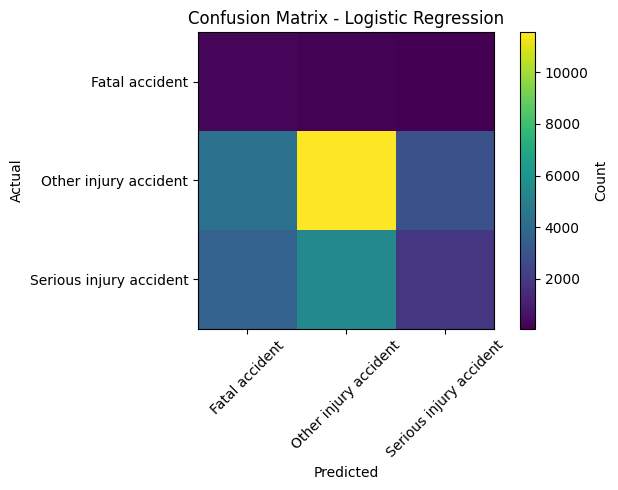

In [15]:
# -----------------------------
# 9. Evaluate Logistic Regression
# -----------------------------
print("Classification Report - Logistic Regression")
print(classification_report(
    y_test,
    logistic_preds,
    target_names=label_encoder.classes_
))

logistic_cm = confusion_matrix(y_test, logistic_preds)

plt.figure(figsize=(7, 5))
plt.imshow(logistic_cm)
plt.colorbar(label="Count")

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

### Observation

The Logistic Regression model shows moderate overall performance but struggles with class imbalance.

- Recall for fatal accidents is high, but precision is very low, indicating many false positives  
- The model performs better on the majority class (other injury accidents)  
- Serious injury cases are not well captured, with low recall  

Overall, the model prioritises detecting minority classes but sacrifices precision and overall accuracy. This highlights the challenge of imbalanced data and the need for more advanced models.

## Train Baseline Model 2: Decision Tree

Train a Decision Tree model to capture non-linear relationships between features.

In [16]:
# -----------------------------
# 10. Train Decision Tree model
# -----------------------------
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        ("classifier", DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

tree_preds = decision_tree_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


### Observation

The Decision Tree model was trained as a non-linear baseline. It can capture feature interactions and complex patterns that Logistic Regression may not detect, while class weighting helps address imbalance.

## Evaluate Decision Tree

Evaluate Decision Tree performance using classification metrics and confusion matrix.

Classification Report - Decision Tree
                         precision    recall  f1-score   support

         Fatal accident       0.03      0.51      0.07       507
  Other injury accident       0.67      0.61      0.64     18827
Serious injury accident       0.39      0.20      0.27     11056

               accuracy                           0.46     30390
              macro avg       0.36      0.44      0.32     30390
           weighted avg       0.56      0.46      0.49     30390



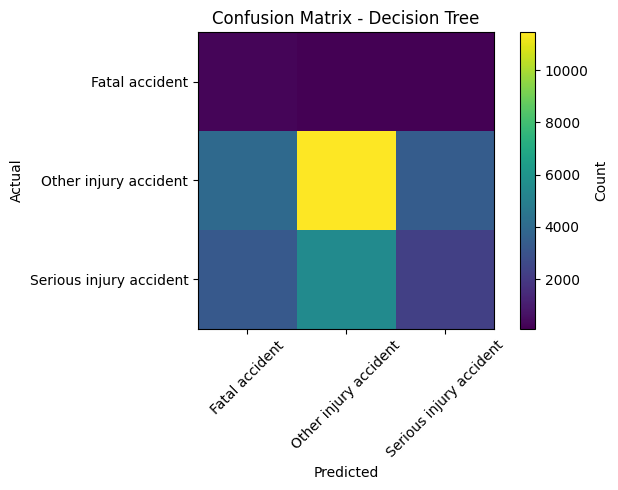

In [17]:
# -----------------------------
# 11. Evaluate Decision Tree
# -----------------------------
print("Classification Report - Decision Tree")
print(classification_report(
    y_test,
    tree_preds,
    target_names=label_encoder.classes_
))

tree_cm = confusion_matrix(y_test, tree_preds)

plt.figure(figsize=(7, 5))
plt.imshow(tree_cm)
plt.colorbar(label="Count")

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

### Observation

The Decision Tree model shows similar overall performance to Logistic Regression, with a slight improvement in capturing serious injury cases.

- Recall for fatal accidents remains moderate, but precision is still very low  
- Performance on the majority class (other injury) is consistent  
- Slight improvement is observed for serious injury recall compared to Logistic Regression  

Overall, the Decision Tree captures some non-linear patterns but still struggles with class imbalance, indicating the need for more advanced models.

## Baseline Model Comparison

Compare Logistic Regression and Decision Tree using key evaluation metrics.

In [18]:
# -----------------------------
# 12. Compare baseline models
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

comparison_results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, logistic_preds),
    evaluate_model("Decision Tree", y_test, tree_preds)
])

comparison_results

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.451102,0.364228,0.449774,0.314139,0.557436,0.451102,0.484276
1,Decision Tree,0.459526,0.364736,0.442278,0.323380,0.556985,0.459526,0.493191


### Observation

Both baseline models show similar performance across most metrics.

- Decision Tree achieves slightly higher accuracy and F1-score  
- Macro scores remain low for both models, reflecting poor performance on minority classes  
- Weighted scores are higher, indicating dominance of the majority class  

Overall, both models struggle with class imbalance, and their performance highlights the need for more advanced models.

## Visualise Model Comparison

Visual comparison of baseline model performance across key metrics.

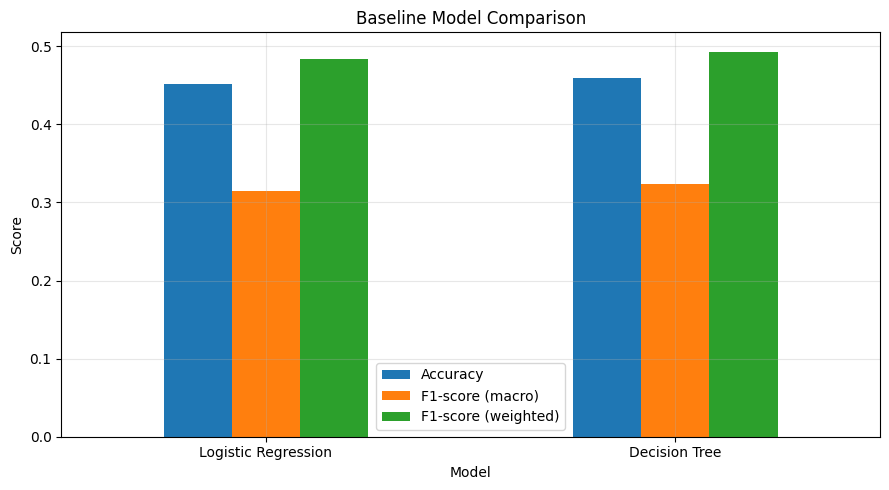

In [19]:
# -----------------------------
# 13. Visualise baseline model comparison
# -----------------------------
metrics_to_plot = ["Accuracy", "F1-score (macro)", "F1-score (weighted)"]

comparison_plot_df = comparison_results.set_index("Model")[metrics_to_plot]

comparison_plot_df.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Score")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observation

The Decision Tree slightly outperforms Logistic Regression across all metrics.

- Weighted scores are higher than macro scores, indicating strong influence of the majority class  
- Macro F1-score remains low for both models, confirming poor performance on minority classes  

This visual comparison highlights the limitations of baseline models and supports the need for advanced modelling.

## Feature Importance (Decision Tree)

Analyse feature importance to understand key predictors influencing crash severity.

                  Feature  Importance
3      speed_zone_numeric    0.576552
0             hour_of_day    0.128727
8    Min temperature (°C)    0.072021
9        Max Humidity (%)    0.067179
7    Max temperature (°C)    0.044200
10  max wind speed (km/h)    0.031968
6     Total Rainfall (mm)    0.031304
5         bicycle_density    0.017159
4      pedestrian_density    0.016976
2               rush_hour    0.007791
1            weekend_flag    0.006124


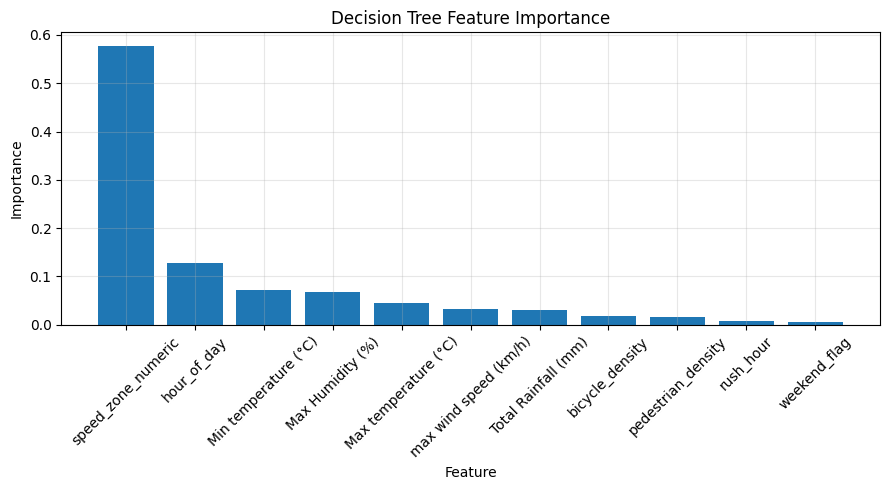

In [20]:
# -----------------------------
# 14. Decision Tree feature importance
# -----------------------------
tree_classifier = decision_tree_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(9, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observation

Speed zone is the most influential feature by a large margin, indicating its strong impact on crash severity.

- Temporal features like hour of day also contribute meaningfully  
- Weather features have moderate influence  
- Mobility features have relatively low importance in this model  

Overall, crash severity appears to be driven more by road conditions and traffic patterns than by weather or mobility alone.

## Save Model Outputs

Save baseline results for reporting and team use.

In [23]:
# -----------------------------
# 15. Save baseline results
# -----------------------------
from pathlib import Path

OUTPUT_DIR = Path("data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_file = OUTPUT_DIR / "baseline_model_comparison.csv"
feature_importance_file = OUTPUT_DIR / "decision_tree_feature_importance.csv"

comparison_results.to_csv(comparison_file, index=False)
feature_importance.to_csv(feature_importance_file, index=False)

print("Saved files:")
print("-", comparison_file)
print("-", feature_importance_file)

Saved files:
- data/outputs/baseline_model_comparison.csv
- data/outputs/decision_tree_feature_importance.csv


### Observation

Baseline model results and feature importance were saved for use in advanced modelling, reporting, and dashboard development. These outputs support comparison with advanced models and integration with the frontend.

In [22]:
# -----------------------------
# Download feature files (optional)
# -----------------------------
from google.colab import files

files.download(str(comparison_file))
files.download(str(feature_importance_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Dashboard Handoff Notes

The following outputs are prepared for dashboard integration:

- Baseline model comparison scores  
- Confusion matrix visualisations  
- Decision Tree feature importance  
- Key modelling insights  

These can support dashboard features such as:

- Model performance comparison (baseline vs advanced)  
- Feature importance visualisation  
- Class-wise prediction performance  
- Risk prediction outputs (to be integrated after final model selection)

## Final Summary

Baseline models (Logistic Regression and Decision Tree) were trained and evaluated on the validated dataset.

Both models show similar performance, with limitations due to class imbalance, especially in predicting fatal accidents.

Key insights:
- Speed zone is the most important feature
- Class imbalance significantly impacts model performance
- Baseline models provide a benchmark for advanced models

These results will be used for comparison in advanced modelling and for generating insights in the project dashboard.